# Keyless data versioning, demonstrated

Most version-control-for-data tools assume every row has a stable **primary key**. A huge amount of real data has none: CSV exports, scraped tables, sensor dumps, public ML datasets. Without a key, a tool cannot tell the difference between

* a row that was **edited** (one cell corrected), and
* a row that was **deleted** and a brand-new row **inserted**.

Guessing wrong wastes storage and destroys the audit trail. **DeltaTrace** recovers row identity from content -- exact hashing first, then a tolerance-aware fuzzy pass -- so an edit is stored as a few changed cells instead of a delete + insert.

The punchline of this notebook: that guess is an *optimisation*, never a *risk*. Reconstruction is always exact, no matter how the matcher is tuned (**error confinement**).

In [1]:
import sys, pathlib
# make the repo root importable whether this runs from notebooks/ or the root
_root = pathlib.Path.cwd()
while not (_root / "benchmarks").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


## A tiny keyless table

Five weather readings. There is no id column -- a row *is* its values. Between v1 and v2 we correct one Lyon reading, add Marseille, and drop Nice.

In [2]:
from deltatrace import DeltaRepo, ContentMatchIdentity
import tempfile, pathlib

v1 = pd.DataFrame({
    "city":   ["Paris", "Paris",    "Lyon", "Lyon",     "Nice"],
    "metric": ["temp",  "humidity", "temp", "humidity", "temp"],
    "value":  [12.0,     60.0,       11.0,   65.0,        15.0],
})
v2 = pd.DataFrame({
    "city":   ["Paris", "Paris",    "Lyon", "Lyon",     "Marseille"],
    "metric": ["temp",  "humidity", "temp", "humidity", "temp"],
    "value":  [12.0,     60.0,       11.4,   65.0,        17.0],
})
display(v1); display(v2)

,city,metric,value
0,Paris,temp,12.0
1,Paris,humidity,60.0
2,Lyon,temp,11.0
3,Lyon,humidity,65.0
4,Nice,temp,15.0


,city,metric,value
0,Paris,temp,12.0
1,Paris,humidity,60.0
2,Lyon,temp,11.4
3,Lyon,humidity,65.0
4,Marseille,temp,17.0


## DeltaTrace recognises the edit

We commit both versions with `ContentMatchIdentity`. The Lyon temperature row (11.0 -> 11.4) is recovered as an **update**, Marseille as an **insert**, Nice as a **delete**.

In [3]:
root = pathlib.Path(tempfile.mkdtemp()) / "demo"
repo = DeltaRepo.init(root, identity=ContentMatchIdentity(block_on=["city", "metric"]))
repo.commit(v1, "v1")
r = repo.commit(v2, "v2")
print("commit stats:", r.stats)
print("\nhow each v2 row was identified:")
repo.explain_last()

commit stats: {'added': 1, 'deleted': 1, 'updated': 1, 'columns_added': 0, 'columns_removed': 0, 'types_changed': 0}

how each v2 row was identified:


,__dt_rid__,row,method,confidence
0,8515d4a0833e43ea,0,exact,1.0
1,8e2017cc40c14abd,1,exact,1.0
2,4354e8988b544983,2,fuzzy,1.0
3,cdb5c530b4b14314,3,exact,1.0
4,d73949b9c49447b9,4,insert,NaN


## What a hash-only keyless system does instead

`exact_only=True` disables the fuzzy pass -- the best a content-hashing system can do. The corrected Lyon row no longer hashes to anything in v1, so it becomes a **delete + insert**. Two row-writes to record a single-cell correction, and the link to the original row is lost.

In [4]:
root2 = pathlib.Path(tempfile.mkdtemp()) / "demo_hash"
repo2 = DeltaRepo.init(root2, identity=ContentMatchIdentity(block_on=["city", "metric"], exact_only=True))
repo2.commit(v1, "v1")
r2 = repo2.commit(v2, "v2")
print("hash-only stats:", r2.stats)
print("DeltaTrace stats:", r.stats)
print("\nSame edit -> hash-only records", r2.stats["added"], "inserts +",
      r2.stats["deleted"], "deletes; DeltaTrace records", r.stats["updated"], "update.")

hash-only stats: {'added': 2, 'deleted': 2, 'updated': 0, 'columns_added': 0, 'columns_removed': 0, 'types_changed': 0}
DeltaTrace stats: {'added': 1, 'deleted': 1, 'updated': 1, 'columns_added': 0, 'columns_removed': 0, 'types_changed': 0}

Same edit -> hash-only records 2 inserts + 2 deletes; DeltaTrace records 1 update.


## Error confinement: a wrong guess never corrupts data

The matcher has a `row_threshold` knob (0 = match almost anything, 1 = match nothing). We sweep it across a synthetic keyless history and, for every setting, check (a) total storage and (b) whether every version reconstructs **exactly**.

Storage moves with the threshold -- a worse match means more delete+insert churn. Correctness does not move at all.

In [5]:
from benchmarks.datasets import load
from benchmarks.synth import make_chain
from benchmarks.systems import run_system, _multiset
from benchmarks.datasets import DATASETS

spec = DATASETS["iris"]
chain = make_chain(load("iris"), update_cols=spec.update_cols, n_versions=8, seed=1)

rows = []
for t in [0.0, 0.05, 0.3, 0.6, 0.9, 1.0]:
    wd = pathlib.Path(tempfile.mkdtemp())
    ident = ContentMatchIdentity(block_on=spec.block_on, row_threshold=t, num_rel_tol=0.25)
    repo3 = DeltaRepo.init(wd / "s", identity=ident, overwrite=True)
    for v in chain:
        repo3.commit(v.payload)
    ok = all(_multiset(repo3.checkout(i + 1)) == _multiset(v.payload) for i, v in enumerate(chain))
    kb = sum(f.stat().st_size for f in (wd / "s").rglob("*") if f.is_file()) / 1024
    rows.append({"row_threshold": t, "storage_kb": round(kb, 1), "reconstructs_exactly": ok})
sweep = pd.DataFrame(rows)
sweep

,row_threshold,storage_kb,reconstructs_exactly
0,0.00,69.3,True
1,0.05,69.3,True
2,0.30,69.3,True
3,0.60,67.2,True
4,0.90,65.1,True
5,1.00,58.1,True


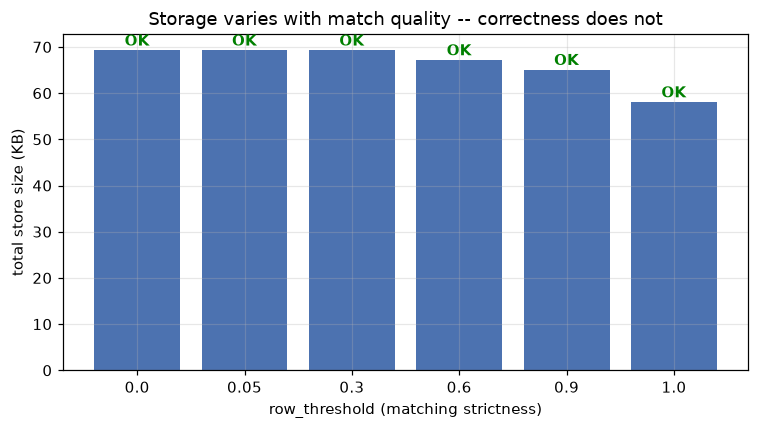

Every threshold reconstructs all 8 versions exactly.


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sweep["row_threshold"].astype(str), sweep["storage_kb"], color="#4C72B0")
ax.set_xlabel("row_threshold (matching strictness)")
ax.set_ylabel("total store size (KB)")
ax.set_title("Storage varies with match quality -- correctness does not")
for i, ok in enumerate(sweep["reconstructs_exactly"]):
    ax.text(i, sweep["storage_kb"].iloc[i] + 1, "OK" if ok else "X",
            ha="center", color="green" if ok else "red", fontweight="bold")
plt.tight_layout(); plt.show()
assert sweep["reconstructs_exactly"].all(), "error confinement violated!"
print("Every threshold reconstructs all", len(chain), "versions exactly.")

### Takeaway

Identity matching trades **storage and provenance quality**, never **correctness**. That is what makes a heuristic matcher safe to ship: the worst a bad guess can do is cost a little space, never corrupt a byte of your data.